# Sección 5.4 - Resampling Methods (ISLP)
## Ejercicios Conceptuales y Aplicados



Francisco Tinoco

---

# Parte 1: Ejercicios Conceptuales

### Ejercicio 1
Usando propiedades básicas de la varianza y cálculo de una variable, deriva (5.6). En otras palabras, prueba que α dado por (5.6) minimiza Var(αX + (1 − α)Y).

---


Queremos minimizar: Var(αX + (1-α)Y)

Expandiendo:
Var(αX + (1-α)Y) = α²σ²ₓ + (1-α)²σ²ᵧ + 2α(1-α)σₓᵧ

Derivando respecto a α e igualando a 0:
d/dα = 2ασ²ₓ - 2(1-α)σ²ᵧ + 2(1-2α)σₓᵧ = 0

Resolviendo:
α = (σ²ᵧ - σₓᵧ) / (σ²ₓ + σ²ᵧ - 2σₓᵧ)

Que es exactamente la ecuación (5.6) del libro.

### Ejercicio 2
Derivaremos la probabilidad de que una observación esté en una muestra bootstrap. Supongamos que obtenemos una muestra bootstrap de un conjunto de n observaciones.

(a) ¿Cuál es la probabilidad de que la primera observación bootstrap no sea la j-ésima de la muestra original?  
(b) ¿Cuál es la probabilidad de que la segunda observación bootstrap no sea la j-ésima de la muestra original?  
(c) Argumenta que la probabilidad de que la j-ésima observación no esté en la muestra bootstrap es (1 − 1/n)ⁿ.  
(d) Cuando n = 5, ¿cuál es la probabilidad de que la j-ésima observación esté en la muestra bootstrap?  
(e) Cuando n = 100, ¿cuál es la probabilidad de que la j-ésima observación esté en la muestra bootstrap?  
(f) Cuando n = 10,000, ¿cuál es la probabilidad de que la j-ésima observación esté en la muestra bootstrap?  
(g) Crea un gráfico que muestre, para cada entero n de 1 a 100,000, la probabilidad de que la j-ésima observación esté en la muestra bootstrap. Comenta lo que observas.  
(h) Investiga numéricamente la probabilidad de que una muestra bootstrap de tamaño n = 100 contenga la observación j = 4.

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt

* (a) P(primera obs != j) = 1 - 1/n

* (b) P(segunda obs != j) = 1 - 1/n (mismo, son independientes)

* (c) P(j no está en bootstrap) = (1 - 1/n)^n

In [2]:
# (d) n=5
n = 5
prob_no = (1 - 1/n)**n
prob_si = 1 - prob_no
print(f"n=5: P(j en bootstrap) = {prob_si:.4f}")

# (e) n=100
n = 100
prob_si = 1 - (1 - 1/n)**n
print(f"n=100: P(j en bootstrap) = {prob_si:.4f}")

# (f) n=10000
n = 10000
prob_si = 1 - (1 - 1/n)**n
print(f"n=10000: P(j en bootstrap) = {prob_si:.4f}")

n=5: P(j en bootstrap) = 0.6723
n=100: P(j en bootstrap) = 0.6340
n=10000: P(j en bootstrap) = 0.6321


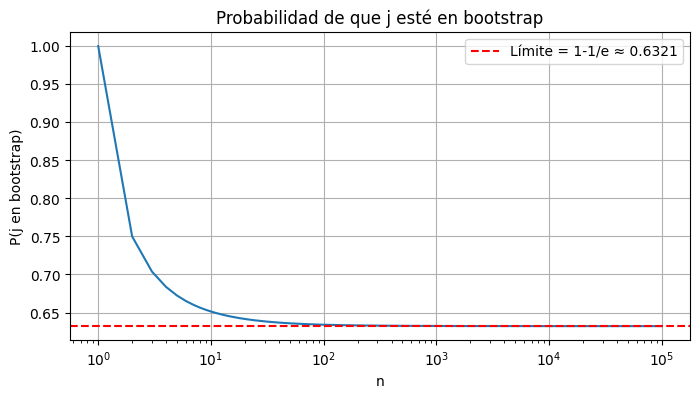

In [3]:
# (g) Gráfico
n_vals = np.arange(1, 100001)
prob = 1 - (1 - 1/n_vals)**n_vals

plt.figure(figsize=(8,4))
plt.plot(n_vals, prob)
plt.axhline(y=1-np.exp(-1), color='r', linestyle='--', label=f'Límite = 1-1/e ≈ {1-np.exp(-1):.4f}')
plt.xlabel('n')
plt.ylabel('P(j en bootstrap)')
plt.title('Probabilidad de que j esté en bootstrap')
plt.legend()
plt.xscale('log')
plt.grid()
plt.show()

In [4]:
# (h) Simulación n=100, j=4
np.random.seed(42)
n = 100
n_sims = 10000
j = 4

cuenta = 0
for _ in range(n_sims):
    muestra = np.random.choice(n, size=n, replace=True)
    if j in muestra:
        cuenta += 1

print(f"P(j=4 en bootstrap) simulada = {cuenta/n_sims:.4f}")
print(f"P(j=4 en bootstrap) teórica = {1 - (1-1/n)**n:.4f}")

P(j=4 en bootstrap) simulada = 0.6369
P(j=4 en bootstrap) teórica = 0.6340


## Ejercicios Prácticos

### Ejercicio 3
Revisamos *k*-fold cross-validation.  
(a) Explica cómo se implementa *k*-fold cross-validation.  
(b) Ventajas y desventajas de *k*-fold cross-validation respecto a:  
   i. El enfoque de conjunto de validación.  
   ii. LOOCV.

---

**(a) Implementación:**
1. Dividir datos en k grupos (folds) del mismo tamaño
2. Para i = 1 a k:
   - Usar fold i como validación
   - Usar los otros k-1 folds como entrenamiento
   - Calcular error en fold i
3. Promediar los k errores

**(b) Ventajas/Desventajas:**

vs Validation Set:
- ✓ Usa más datos para entrenar
- ✓ Menos varianza en la estimación
- ✗ Más costoso computacionalmente

vs LOOCV:
- ✓ Menos costoso (k modelos vs n modelos)
- ✓ Menor varianza (folds menos correlacionados)
- ✗ Ligeramente más sesgo

### Ejercicio 4
Supongamos que usamos un método de aprendizaje estadístico para predecir la respuesta *Y* para un valor particular del predictor *X*. Describe cuidadosamente cómo podríamos estimar la desviación estándar de nuestra predicción.

---




Usando Bootstrap:
1. Generar B muestras bootstrap del dataset
2. Para cada muestra, ajustar el modelo y predecir ŷ para X dado
3. Calcular la desviación estándar de las B predicciones:
   
   SE(ŷ) = sqrt(1/(B-1) * Σ(ŷᵢ - ŷ_promedio)²)

### Ejercicio 5 (Applied)
En el Capítulo 4 usamos regresión logística para predecir la probabilidad de default usando income y balance en el conjunto de datos *Default*. Ahora estimaremos el error de prueba de este modelo usando el enfoque de conjunto de validación.  

(a) Ajusta un modelo de regresión logística que use income y balance para predecir default.  
(b) Usando el enfoque de conjunto de validación, estima el error de prueba del modelo.  
   i. Divide la muestra en conjunto de entrenamiento y validación.  
   ii. Ajusta el modelo usando solo las observaciones de entrenamiento.  
   iii. Obtén predicciones de default para cada observación en el conjunto de validación, clasificando como default si la probabilidad posterior es mayor a 0.5.  
   iv. Calcula el error de validación como la fracción de observaciones mal clasificadas.  
(c) Repite el proceso en (b) tres veces con diferentes divisiones. Comenta los resultados.  
(d) Considera ahora un modelo que incluya income, balance y una variable dummy para student. Estima el error de prueba y comenta si incluir student reduce la tasa de error.

---

In [3]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
!pip install ISLP


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=fce841c3a4de1eae3d860ee78146f398e7473aad07eb9872ca350b05c30ea560
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [4]:
from ISLP import load_data
Default = load_data('Default')
Default['default_bin'] = (Default['default'] == 'Yes').astype(int)
Default['student_bin'] = (Default['student'] == 'Yes').astype(int)
Default.head()

,default,student,balance,income,default_bin,student_bin
0,No,No,729.526495,44361.625074,0,0
1,No,Yes,817.180407,12106.134700,0,1
2,No,No,1073.549164,31767.138947,0,0
3,No,No,529.250605,35704.493935,0,0
4,No,No,785.655883,38463.495879,0,0


In [9]:
# (a) y (b) Modelo con income y balance
X = Default[['income', 'balance']]
Y = Default['default_bin']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

error = 1 - accuracy_score(y_test, y_pred)
error

0.026666666666666616

In [10]:
# (c) Repetir con diferentes semillas
for seed in [1, 2, 3]:
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=seed)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    error = 1 - accuracy_score(y_test, y_pred)
    print(f"Seed {seed}: Error = {error:.4f}")

Seed 1: Error = 0.0247
Seed 2: Error = 0.0237
Seed 3: Error = 0.0250


El error varía según la división (variabilidad del validation set approach)

In [11]:
# (d) Incluir student
X_student = Default[['income', 'balance', 'student_bin']]

X_train, X_test, y_train, y_test = train_test_split(X_student, Y, test_size=0.3, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

error_student = 1 - accuracy_score(y_test, y_pred)
error_student

0.026666666666666616

### Ejercicio 6
Continuamos con el modelo de regresión logística para predecir default usando income y balance en el conjunto *Default*. Calcularemos errores estándar de los coeficientes de income y balance de dos formas: (1) usando bootstrap, y (2) usando la fórmula estándar en `sm.GLM()`.  

(a) Usando `summarize()` y `sm.GLM()`, determina los errores estándar estimados para los coeficientes.  
(b) Escribe una función `boot_fn()` que tome como entrada el conjunto *Default* y un índice de observaciones, y devuelva los coeficientes de income y balance.  
(c) Usando tu función `boot_fn()`, estima los errores estándar de los coeficientes mediante bootstrap.  
(d) Comenta los errores estándar obtenidos con `sm.GLM()` y con bootstrap.

---


In [7]:
import statsmodels.api as sm

In [14]:
# (a) Errores estándar con GLM
X = Default[['income', 'balance']]
X_sm = sm.add_constant(X)
Y = Default['default_bin']

modelo = sm.GLM(Y, X_sm, family=sm.families.Binomial()).fit()
print("Errores estándar (GLM):")
modelo.bse

Errores estándar (GLM):


,0
const,0.434772
income,0.000005
balance,0.000227


In [15]:
# (b) y (c) Bootstrap
def boot_fn(data, idx):
    X_boot = sm.add_constant(data[['income', 'balance']].iloc[idx])
    Y_boot = data['default_bin'].iloc[idx]
    modelo = sm.GLM(Y_boot, X_boot, family=sm.families.Binomial()).fit(disp=0)
    return modelo.params.values

np.random.seed(42)
n = len(Default)
n_boot = 1000
coefs = []

for _ in range(n_boot):
    idx = np.random.choice(n, size=n, replace=True)
    coefs.append(boot_fn(Default, idx))

coefs = np.array(coefs)
print("\nErrores estándar (Bootstrap):")
print(f"  const:   {np.std(coefs[:,0]):.6f}")
print(f"  income:  {np.std(coefs[:,1]):.8f}")
print(f"  balance: {np.std(coefs[:,2]):.6f}")


Errores estándar (Bootstrap):
  const:   0.434501
  income:  0.00000497
  balance: 0.000232


### Ejercicio 7
En las secciones 5.1.2 y 5.1.3 vimos que `cross_validate()` puede usarse para calcular el error LOOCV. Alternativamente, se puede calcular con `sm.GLM()` y `predict()` dentro de un ciclo.  

Implementa este enfoque para calcular el error LOOCV de un modelo de regresión logística simple en el conjunto *Weekly*. Recuerda que en problemas de clasificación, el error LOOCV se define en (5.4).

---



In [5]:
# LOOCV manual para regresión logística en Weekly
Weekly = load_data('Weekly')
Weekly['Direction_bin'] = (Weekly['Direction'] == 'Up').astype(int)

X = Weekly[['Lag1', 'Lag2']]
Y = Weekly['Direction_bin']
n = len(Weekly)

In [8]:
errores = []
for i in range(n):
    # Train sin observación i
    X_train = X.drop(i)
    y_train = Y.drop(i)
    X_test = X.iloc[[i]]
    y_test = Y.iloc[i]

    X_train_sm = sm.add_constant(X_train)
    X_test_sm = sm.add_constant(X_test)

    modelo = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial()).fit(disp=0)
    prob = modelo.predict(X_test_sm)[0]
    pred = 1 if prob > 0.5 else 0

    errores.append(pred != y_test)

loocv_error = np.mean(errores)
loocv_error

ValueError: shapes (1,2) and (3,) not aligned: 2 (dim 1) != 3 (dim 0)

### Ejercicio 8
Realiza validación cruzada en un conjunto de datos simulado.  

(a) Genera un conjunto de datos simulado con:  
```python
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

In [19]:
# (a) Generar datos
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2*x**2 + rng.normal(size=100)

print(f"n = 100, p = 1")
print("Modelo: Y = X - 2X² + ε")

n = 100, p = 1
Modelo: Y = X - 2X² + ε


(a) ¿Cuáles son *n* y *p*? Escribe el modelo en forma de ecuación.

(b) Haz un diagrama de dispersión de *X* contra *Y*. Comenta lo que observas.

(c) Calcula los errores LOOCV al ajustar los siguientes modelos:

i. \( Y = \beta_0 + \beta_1 X + \epsilon \)  

ii. \( Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \epsilon \)  

iii. \( Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon \)  

iv. \( Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \beta_4 X^4 + \epsilon \)  


(d) Repite (c) con otra semilla aleatoria. ¿Los resultados son iguales? Explica.


(e) ¿Cuál modelo tuvo el menor error LOOCV? ¿Era lo esperado?


(f) Comenta la significancia estadística de los coeficientes en cada modelo y si concuerda con las conclusiones de la validación cruzada.

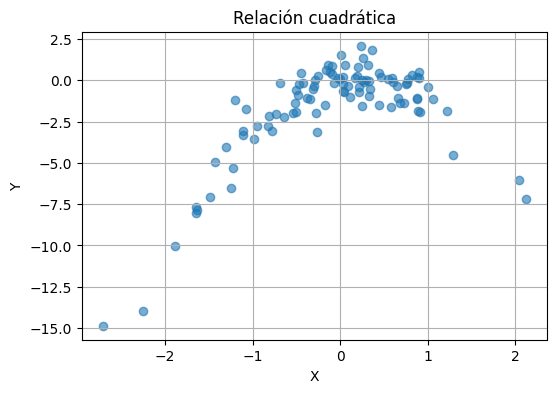

In [20]:
# (b) Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(x, y, alpha=0.6)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Relación cuadrática')
plt.grid()
plt.show()
# Se observa una relación cuadrática (parábola)

In [21]:
# (c) LOOCV para 4 modelos
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.preprocessing import PolynomialFeatures

X_base = x.reshape(-1, 1)

for grado in [1, 2, 3, 4]:
    poly = PolynomialFeatures(degree=grado, include_bias=False)
    X_poly = poly.fit_transform(X_base)

    lr = LinearRegression()
    scores = cross_val_score(lr, X_poly, y, cv=LeaveOneOut(), scoring='neg_mean_squared_error')
    loocv_mse = -scores.mean()
    print(f"Grado {grado}: LOOCV MSE = {loocv_mse:.4f}")

Grado 1: LOOCV MSE = 6.6330
Grado 2: LOOCV MSE = 1.1229
Grado 3: LOOCV MSE = 1.3018
Grado 4: LOOCV MSE = 1.3324


In [22]:
# (d) Repetir con otra semilla
rng2 = np.random.default_rng(42)
x2 = rng2.normal(size=100)
y2 = x2 - 2*x2**2 + rng2.normal(size=100)
X_base2 = x2.reshape(-1, 1)

print("\nCon otra semilla:")
for grado in [1, 2, 3, 4]:
    poly = PolynomialFeatures(degree=grado, include_bias=False)
    X_poly = poly.fit_transform(X_base2)

    lr = LinearRegression()
    scores = cross_val_score(lr, X_poly, y2, cv=LeaveOneOut(), scoring='neg_mean_squared_error')
    loocv_mse = -scores.mean()
    print(f"Grado {grado}: LOOCV MSE = {loocv_mse:.4f}")

# Resultados similares porque LOOCV no tiene aleatoriedad


Con otra semilla:
Grado 1: LOOCV MSE = 4.2519
Grado 2: LOOCV MSE = 0.9640
Grado 3: LOOCV MSE = 0.9913
Grado 4: LOOCV MSE = 1.0182


**(e)** El modelo de grado 2 tiene menor error, lo cual es esperado porque los datos fueron generados con Y = X - 2X².

**(f)** Los coeficientes de X y X² son significativos, mientras que X³ y X⁴ no lo son, lo cual concuerda con LOOCV.

### Ejercicio 9
Usaremos el conjunto de datos *Boston* de la librería ISLP.  

(a) Proporciona una estimación de la media poblacional de *medv*. Llama a esta estimación μ̂.  
(b) Estima el error estándar de μ̂. Interpreta el resultado.  
(c) Estima el error estándar de μ̂ usando bootstrap. Compara con (b).  
(d) Con tu estimación bootstrap, proporciona un intervalo de confianza del 95% para la media de *medv*. Compáralo con el obtenido usando la regla de dos errores estándar.  
(e) Proporciona una estimación de la mediana poblacional de *medv*. Llama a esta estimación μ̂_med.  
(f) Estima el error estándar de μ̂_med usando bootstrap. Comenta tus hallazgos.  
(g) Proporciona una estimación para el percentil 10 de *medv*. Llama a esta cantidad μ̂_0.1.  
(h) Usa bootstrap para estimar el error estándar de μ̂_0.1. Comenta tus hallazgos.

---


In [23]:
Boston = load_data('Boston')
medv = Boston['medv']

In [24]:
# (a) Media muestral
mu_hat = medv.mean()
print(f"μ̂ = {mu_hat:.4f}")

μ̂ = 22.5328


In [26]:
# (b) Error estándar de la media
se_mu = medv.std() / np.sqrt(len(medv))
se_mu

np.float64(0.4088611474975351)

In [27]:
# (c) Bootstrap para SE
np.random.seed(42)
n = len(medv)
n_boot = 1000
medias_boot = []

for _ in range(n_boot):
    muestra = medv.sample(n=n, replace=True)
    medias_boot.append(muestra.mean())

se_boot = np.std(medias_boot)
print(f"SE(μ̂) bootstrap = {se_boot:.4f}")
# Muy similar al método clásico

SE(μ̂) bootstrap = 0.3969


In [28]:
# (d) Intervalo de confianza 95%
media_boot = np.mean(medias_boot)
ci_boot = [media_boot - 1.96*se_boot, media_boot + 1.96*se_boot]
ci_clasico = [mu_hat - 1.96*se_mu, mu_hat + 1.96*se_mu]

print(f"IC 95% Bootstrap: [{ci_boot[0]:.4f}, {ci_boot[1]:.4f}]")
print(f"IC 95% Clásico:   [{ci_clasico[0]:.4f}, {ci_clasico[1]:.4f}]")

IC 95% Bootstrap: [21.7595, 23.3153]
IC 95% Clásico:   [21.7314, 23.3342]


In [30]:
# (e) Mediana
mu_med = medv.median()
mu_med

21.2

In [31]:
# (f) Bootstrap para SE de mediana
medianas_boot = []
for _ in range(n_boot):
    muestra = medv.sample(n=n, replace=True)
    medianas_boot.append(muestra.median())

se_mediana = np.std(medianas_boot)
print(f"SE(mediana) bootstrap = {se_mediana:.4f}")
# No hay fórmula cerrada para SE de mediana, bootstrap está bien

SE(mediana) bootstrap = 0.3759


In [34]:
# (g) Percentil 10
mu_10 = medv.quantile(0.1)
mu_10

np.float64(12.75)

In [35]:
# (h) Bootstrap para SE del percentil 10
p10_boot = []
for _ in range(n_boot):
    muestra = medv.sample(n=n, replace=True)
    p10_boot.append(muestra.quantile(0.1))

se_p10 = np.std(p10_boot)
print(f"SE(percentil 10) bootstrap = {se_p10:.4f}")
# Bootstrap es útil para estadísticos sin fórmula cerrada de SE

SE(percentil 10) bootstrap = 0.4991
